<a href="https://colab.research.google.com/github/tamamori3180-hash/-/blob/main/%E6%A5%BD%E6%9B%B2%E5%88%86%E6%9E%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####目的

・説明変数の選択は、説明変数同士の相関係数・モデル構築後のP値などを参考にすること

・カラム数が多すぎると、モデルが過学習してしまうので、モデルに組み込む変数量に注意すること

・目的変数の可視化はマストで、その他変数の可視化も積極的に行うとよい

・目的変数の分布などから変数変換を行うのもよい

・対数変換をした場合はQ-Qプロットというもので変換の正しさを確認できます（調べてみてください！）

・回帰係数のスケールに気をつけること（標準化偏回帰係数を用いると回帰係数間の影響を比べられる）


##・精度を求めるのも大事だが、大目標は自分の仮説を検証すること

##・どのデータが影響しているか、にフォーカスして分析結果報告をしていただくのがゴールです

##・精度を追い求めすぎるのは今回の目的ではないので注意してください！

結論から言うと、「楽曲の中身（テンポやダンスのしやすさ）」よりも、「露出の場（プレイリスト）」が圧倒的に再生数に影響しているという結果が出ました。

この分析結果は、ビジネスにおいて「予算をどこに投下すべきか（制作 vs 宣伝）」を判断する上で非常に強力な根拠になります。

#### ** マウント**

In [ ]:
# Google driveをマウント
# Google ColabでGoogleドライブを使えるようにするためのもの
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 参照ディレクトリの設定
# Google Colab上で「作業するフォルダ（ディレクトリ）」を指定して、そこに移動するためのもの
%cd "/content/drive/MyDrive"

/content/drive/MyDrive


### **インストールおよびインポート**

In [ ]:
# 外部ライブラリのインストール
!pip install japanize-matplotlib # 日本語対応（Matplotlibで日本語を表示）

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 46.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=69e04b24eec2a6b9380edd730bd3e1f9192916358d801800d2e3ccc583b96587
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [ ]:
# 標準ライブラリのインポート
# `as` を使用して、ライブラリを省略し別名でインポート（コードの簡略化）することも可能

# データ処理用
import pandas as pd  # データフレーム操作

# 可視化用
import matplotlib.pyplot as plt  # 可視化
import seaborn as sns  # 可視化
# 外部ライブラリのインポート
import japanize_matplotlib  # 日本語対応（Matplotlibで日本語を表示）

### **読み込み**

In [ ]:
# データセット読み込み（エンコーディングを指定しないとエラーが起きる）
df = pd.read_csv("data/spotify-2023.csv", encoding = "latin-1")

### **統計情報**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [ ]:
df.isnull().sum()

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
in_apple_playlists,0


In [ ]:
df.describe()

### **可視化**

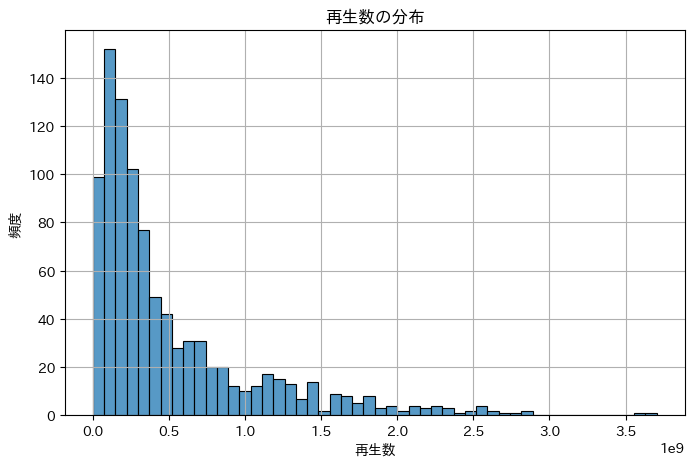

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["streams"], bins=50)
plt.xlabel("再生数")
plt.ylabel("頻度")
plt.title("再生数の分布")
plt.grid()

##多重共線性の確認

In [ ]:
# 目的変数（steram）
# 今回は、数値でない値が入っており、データ型が数値型ではなく、文字型として入っていたことが判明
# そのため、その異常値を削除してから数値型に変更を行う。

# streamsを降順に表示
# indexが574の楽曲「Love Grows」はstreamsに異常値が存在する
df.sort_values(by='streams', ascending=False).head(5)

# streams列の数値でないものをレコードごと削除
df = df[df["streams"] != "BPM110KeyAModeMajorDanceability53Valence75Energy69Acousticness7Instrumentalness0Liveness17Speechiness3"]

# 数値型に変換
df = df.astype({"streams": "int64"})

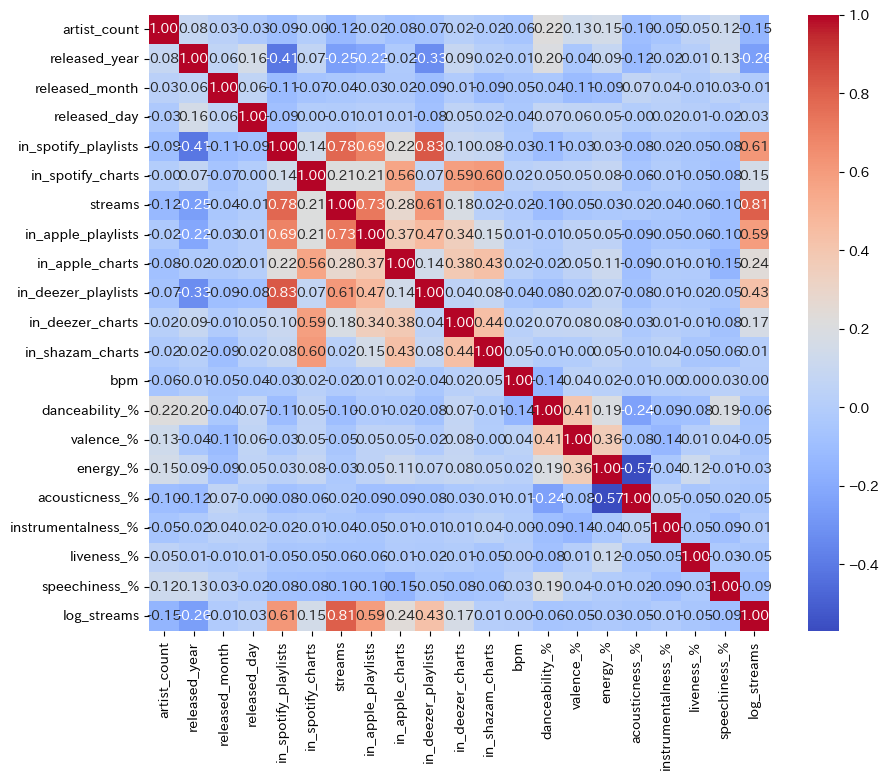

In [ ]:
df_numeric = df.select_dtypes(include=['number'])
sns.heatmap(df_numeric.corr(),annot=True,cmap='coolwarm',fmt=".2f")
fig=plt.gcf()
fig.set_size_inches(10,8)
plt.show()

AppleプレイリストとSpotifyプレイリストには0.7の正の相関がある

Spotifyチャートとディザーチャートには0.6の正の相関

SpotifyチャートとAppleチャートには0.55の正の相関

Enegy とアコースティックは0.6の負の相関

### **前処理（異常値対応 → データ型の変更）**


今回はデータ型がおかしいと思われるカラムが複数存在し、データの可視化に影響を及ぼす。<br>
そのため、データの可視化前に異常値対応およびデータ型の変更を行う。

In [ ]:
# 目的変数（steram）
# 今回は、数値でない値が入っており、データ型が数値型ではなく、文字型として入っていたことが判明
# そのため、その異常値を削除してから数値型に変更を行う。

# streamsを降順に表示
# indexが574の楽曲「Love Grows」はstreamsに異常値が存在する
df.sort_values(by='streams', ascending=False).head(5)

# streams列の数値でないものをレコードごと削除
df = df[df["streams"] != "BPM110KeyAModeMajorDanceability53Valence75Energy69Acousticness7Instrumentalness0Liveness17Speechiness3"]

# 数値型に変換
df = df.astype({"streams": "int64"})

In [ ]:
954-574

380

In [ ]:
# 説明変数（in_deezer_playlists,in_shazam_charts）
# 今回は、数値にカンマが入っており、データ型が数値型ではなく、文字型として入っていたことが判明
# そのため、そのカンマを変換してから数値型に変更を行う。

# カンマ削除・数値変換（float型に変換）
for col in ['in_deezer_playlists', 'in_shazam_charts']:
    df[col] = df[col].str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')  # → float型 + NaNになる

In [ ]:
df[(df["streams"] >= 3.0e9 )]

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
55,Blinding Lights,The Weeknd,1,2019,11,29,43899,69,3703895074,672,...,171,C#,Major,50,38,80,0,0,9,7
179,Shape of You,Ed Sheeran,1,2017,1,6,32181,10,3562543890,33,...,96,C#,Minor,83,93,65,58,0,9,8


有名人気曲であるから異常値とは認めないで対数変換をとる

###欠損値の処理

In [ ]:
df[df["in_shazam_charts"].isna()]

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
14,As It Was,Harry Styles,1,2022,3,31,23575,130,2513188493,403,...,174,F#,Minor,52,66,73,34,0,31,6
54,Another Love,Tom Odell,1,2012,10,15,18371,83,1813673666,250,...,123,E,Minor,45,13,54,70,0,9,4
55,Blinding Lights,The Weeknd,1,2019,11,29,43899,69,3703895074,672,...,171,C#,Major,50,38,80,0,0,9,7
71,Heat Waves,Glass Animals,1,2020,6,28,22543,63,2557975762,386,...,81,B,Major,76,53,53,44,0,9,9
73,Sweater Weather,The Neighbourhood,1,2012,5,14,16413,61,2282771485,166,...,124,A#,Major,61,41,81,5,2,10,3
86,Someone You Loved,Lewis Capaldi,1,2018,11,8,17836,53,2887241814,440,...,110,C#,Major,50,45,41,75,0,11,3
127,Watermelon Sugar,Harry Styles,1,2019,11,17,21915,34,2322580122,437,...,95,NaN,Major,55,56,82,12,0,34,5
158,Ghost,Justin Bieber,1,2021,3,19,5866,24,1167330737,107,...,154,D,Major,61,41,74,21,0,40,6
159,Under The Influence,Chris Brown,1,2019,10,4,3859,26,929964809,133,...,117,A,Minor,73,31,69,6,0,11,4
180,Night Changes,One Direction,1,2014,11,17,7124,18,1131090940,60,...,120,G#,Major,67,40,52,86,0,12,4


In [ ]:
df = df.dropna(subset=['in_shazam_charts'])

📌 spotifyデータセットの説明

| カラム名              | 詳細情報（英語）                                                |  詳細情報（翻訳 + 補足説明）                                                                |
|--------------------------|--------------------------------------------------------|-------------------------------------------------------------------------------------|
| track_name               | Name of the song                                       | 曲名                                                                                |
| artist(s)_name           | Name of the artist(s) of the song                      | 歌手名                                                                              |
| artist_count             | Number of artists contributing to the song            | 楽曲に参加したアーティストの数                                                    |
| released_year            | Year when the song was released                        | リリースされた年                                                                    |
| released_month           | Month when the song was released                       | リリースされた月                                                                    |
| released_day             | Day of the month when the song was released            | リリースされた日                                                                    |
| in_spotify_playlists     | Number of Spotify playlists the song is included in    | 該当する曲が含まれているSpotifyのプレイリストの数                                  |
| in_spotify_charts        | Presence and rank of the song on Spotify charts        | Spotifyのチャートにおける該当する曲の有無と順位                                    |
| streams                  | Total number of streams on Spotify                     | Spotifyでの総ストリーミング数                                                      |
| in_apple_playlists       | Number of Apple Music playlists the song is included in| 該当する曲が含まれているApple Musicのプレイリストの数                              |
| in_apple_charts          | Presence and rank of the song on Apple Music charts    | Apple Musicのチャートにおける該当する曲の有無と順位                                |
| in_deezer_playlists      | Number of Deezer playlists the song is included in     | 該当する曲が含まれているDeezerのプレイリストの数                                   |
| in_deezer_charts         | Presence and rank of the song on Deezer charts         | Deezerのチャートにおける該当する曲の有無と順位                                     |
| in_shazam_charts         | Presence and rank of the song on Shazam charts         | Shazamのチャートにおける該当する曲の有無と順位                                     |
| bpm                      | Beats per minute, a measure of song tempo              | 拍/分、曲のテンポを表す指標                                                        |
| key                      | Key of the song                                        | 曲のキー（曲の調（C, D, E...など）を数値で表したもの）                                                                            |
| mode                     | Mode of the song (major or minor)                      | メジャー（明るい雰囲気）かマイナー（切ない雰囲気）かを示す                                                |
| danceability_%           | Percentage indicating how suitable the song is for dancing | ダンスに適した曲かどうかを示すパーセンテージ                                  |
| valence_%                | Positivity of the song's musical content               | 楽曲の音楽的な内容のポジティブさ                                                  |
| energy_%                 | Perceived energy level of the song                     | 楽曲の認知されたエネルギーレベル                                                  |
| acousticness_%           | Amount of acoustic sound in the song                   | 曲中のアコースティックな音の量（電気を使用しない楽器が奏でる音）                  |
| instrumentalness_%       | Amount of instrumental content in the song             | 曲中のインストゥルメンタルなコンテンツの量（ボーカルを含まない）                  |
| liveness_%               | Presence of live performance elements                  | ライブ・パフォーマンス要素の有無（ライブ録音されたかどうか）                      |
| speechiness_%            | Amount of spoken words in the song                     | 曲中で話されている言葉の量                                                        |


#分析１回目

In [ ]:
# 1. 欲しい列の名前をリストにする
select_columns = ['streams', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts']

# 2. そのリストを使って抽出する（.copy() をつけるのがコツ）
df_selected = df[select_columns].copy()

In [ ]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 902 entries, 0 to 952
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   streams               902 non-null    int64
 1   in_spotify_playlists  902 non-null    int64
 2   in_spotify_charts     902 non-null    int64
 3   in_apple_playlists    902 non-null    int64
 4   in_apple_charts       902 non-null    int64
 5   in_deezer_playlists   902 non-null    int64
 6   in_deezer_charts      902 non-null    int64
 7   in_shazam_charts      902 non-null    int64
dtypes: int64(8)
memory usage: 63.4 KB


##相関分析

In [ ]:
# 相関を確認する
correlation_matrix = df_selected.corr() # 相関行列の計算
correlation_matrix

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts
streams,1.000000,0.784141,0.213424,0.729996,0.277430,0.608748,0.183057,0.024981
in_spotify_playlists,0.784141,1.000000,0.140049,0.689075,0.224976,0.828362,0.104102,0.081143
in_spotify_charts,0.213424,0.140049,1.000000,0.211866,0.562651,0.074484,0.588402,0.602994
in_apple_playlists,0.729996,0.689075,0.211866,1.000000,0.373356,0.466217,0.344785,0.154977
in_apple_charts,0.277430,0.224976,0.562651,0.373356,1.000000,0.144066,0.384740,0.434395
in_deezer_playlists,0.608748,0.828362,0.074484,0.466217,0.144066,1.000000,0.044693,0.077762
in_deezer_charts,0.183057,0.104102,0.588402,0.344785,0.384740,0.044693,1.000000,0.437628
in_shazam_charts,0.024981,0.081143,0.602994,0.154977,0.434395,0.077762,0.437628,1.000000


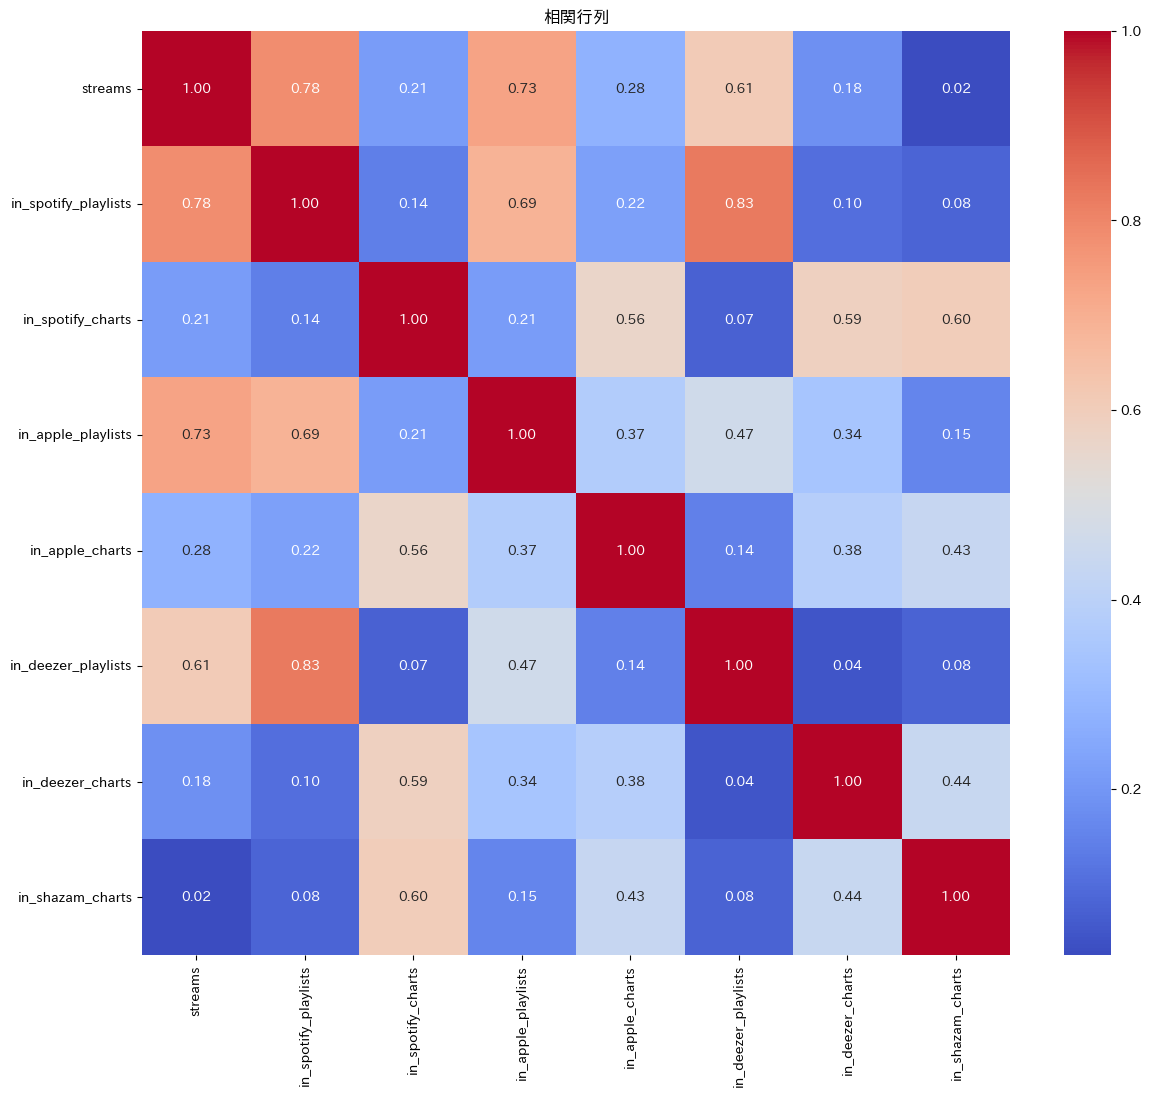

In [ ]:
# ヒートマップによる可視化
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('相関行列')
plt.show()

#annot=True 相関係数の値を入れる　False は色のみ表示
#fmt=".2f" 小数点どこまでか

###多重共線性の確認

プレイリストは正の相関があるがチャートは若干の負の相関

→チャート順位が高い（またはチャートイン数が多い）ことと、累積再生数の多さは必ずしも一致しない。むしろ逆の動きをすることもある。

SpotifyとDeezerプレイリストが1番相関ある

→Spotifyで多くのプレイリストに入っている曲は、Deezerでも同様に多くのプレイリストに入っている確率が非常に高い。

##データ分割

In [ ]:
# 目的変数と説明変数を分ける
X = df_selected.drop(columns=['streams'])  # price (価格) を除いたものが特徴量（説明変数）
y = df_selected['streams']  # price（価格）がターゲット

In [ ]:
from sklearn.model_selection import train_test_split #ライブラリ sklearn

# データ分割（80%を訓練用、20%をテスト用）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#random_state がないと再現性が保たれない

##回帰モデル

In [ ]:
from sklearn.linear_model import LinearRegression

# モデルの作成 & 学習
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train) #sklearnのfit関数

# 予測結果をy_predに代入
y_pred = sklearn_model.predict(X_test) #predict関数


In [ ]:
# 実際にy_pred（予測結果）をデータフレームの形式にして確認してみよう
y_pred_df = pd.DataFrame(y_pred, columns=['streams'])
y_pred_df

,streams
0,2.177644e+09
1,1.171499e+09
2,2.084943e+08
3,2.688439e+08
4,2.637021e+08
...,...
176,1.814362e+08
177,8.017814e+08
178,2.702008e+08
179,1.120131e+09


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 訓練データの予測と評価
y_train_pred = sklearn_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

# 結果の表示
print(f"=== 訓練データ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_train:.4f}")
print(f"R²スコア（決定係数）: {r2_train:.4f}")

print(f"\n=== テストデータ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_test:.4f}")
print(f"R²スコア（決定係数）: {r2_test:.4f}")


=== 訓練データ ===
RMSE（二乗平均平方根誤差）: 280964926.3226
R²スコア（決定係数）: 0.7098

=== テストデータ ===
RMSE（二乗平均平方根誤差）: 282218939.9549
R²スコア（決定係数）: 0.6951


In [ ]:
import statsmodels.api as sm #statsmodelsライブラリ（統計表）
X_train_const = sm.add_constant(X_train)

stats_model = sm.OLS(y_train, X_train_const)
results = stats_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     249.2
Date:                Wed, 26 Nov 2025   Prob (F-statistic):          8.30e-187
Time:                        21:03:41   Log-Likelihood:                -15049.
No. Observations:                 721   AIC:                         3.011e+04
Df Residuals:                     713   BIC:                         3.015e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.265e+08 

##可視化

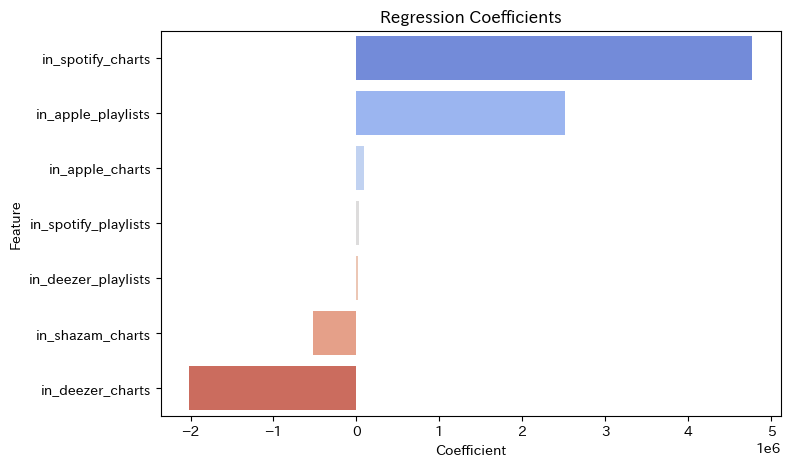

In [ ]:
# 回帰係数の可視化
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': sklearn_model.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=coef_df, palette='coolwarm')
plt.title("Regression Coefficients")
plt.show()

# 「標準化偏回帰係数」も調べてみよう

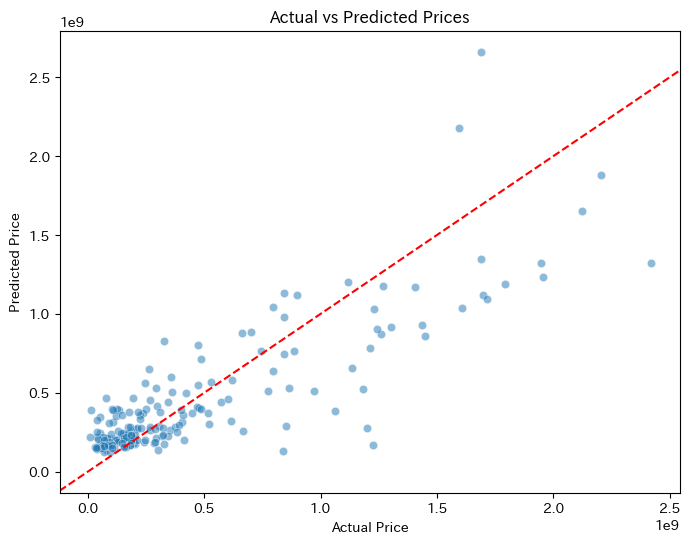

In [ ]:
# 散布図の作成
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual Price")  # 実際の価格
plt.ylabel("Predicted Price")  # 予測価格
plt.title("Actual vs Predicted Prices")
plt.axline([0, 0], [1, 1], color="red", linestyle="--")  # 完全一致のライン
plt.show()
#予測点線

#分析２回目

多重共線性の観点からin_deezer_playlistsを除いて分析した

In [ ]:
# 1. 欲しい列の名前をリストにする
select_columns2 = ['streams', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_apple_charts', 'in_deezer_charts', 'in_shazam_charts']

# 2. そのリストを使って抽出する（.copy() をつけるのがコツ）
df_selected2 = df[select_columns2].copy()

In [ ]:
df_selected2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 902 entries, 0 to 952
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   streams               902 non-null    int64  
 1   in_spotify_playlists  902 non-null    int64  
 2   in_spotify_charts     902 non-null    int64  
 3   in_apple_playlists    902 non-null    int64  
 4   in_apple_charts       902 non-null    int64  
 5   in_deezer_charts      902 non-null    int64  
 6   in_shazam_charts      902 non-null    float64
dtypes: float64(1), int64(6)
memory usage: 56.4 KB


##相関分析

In [ ]:
# 相関を確認する
correlation_matrix2 = df_selected2.corr() # 相関行列の計算
correlation_matrix2

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,in_shazam_charts
streams,1.000000,0.784141,0.213424,0.729996,0.277430,0.183057,0.024981
in_spotify_playlists,0.784141,1.000000,0.140049,0.689075,0.224976,0.104102,0.081143
in_spotify_charts,0.213424,0.140049,1.000000,0.211866,0.562651,0.588402,0.602994
in_apple_playlists,0.729996,0.689075,0.211866,1.000000,0.373356,0.344785,0.154977
in_apple_charts,0.277430,0.224976,0.562651,0.373356,1.000000,0.384740,0.434395
in_deezer_charts,0.183057,0.104102,0.588402,0.344785,0.384740,1.000000,0.437628
in_shazam_charts,0.024981,0.081143,0.602994,0.154977,0.434395,0.437628,1.000000


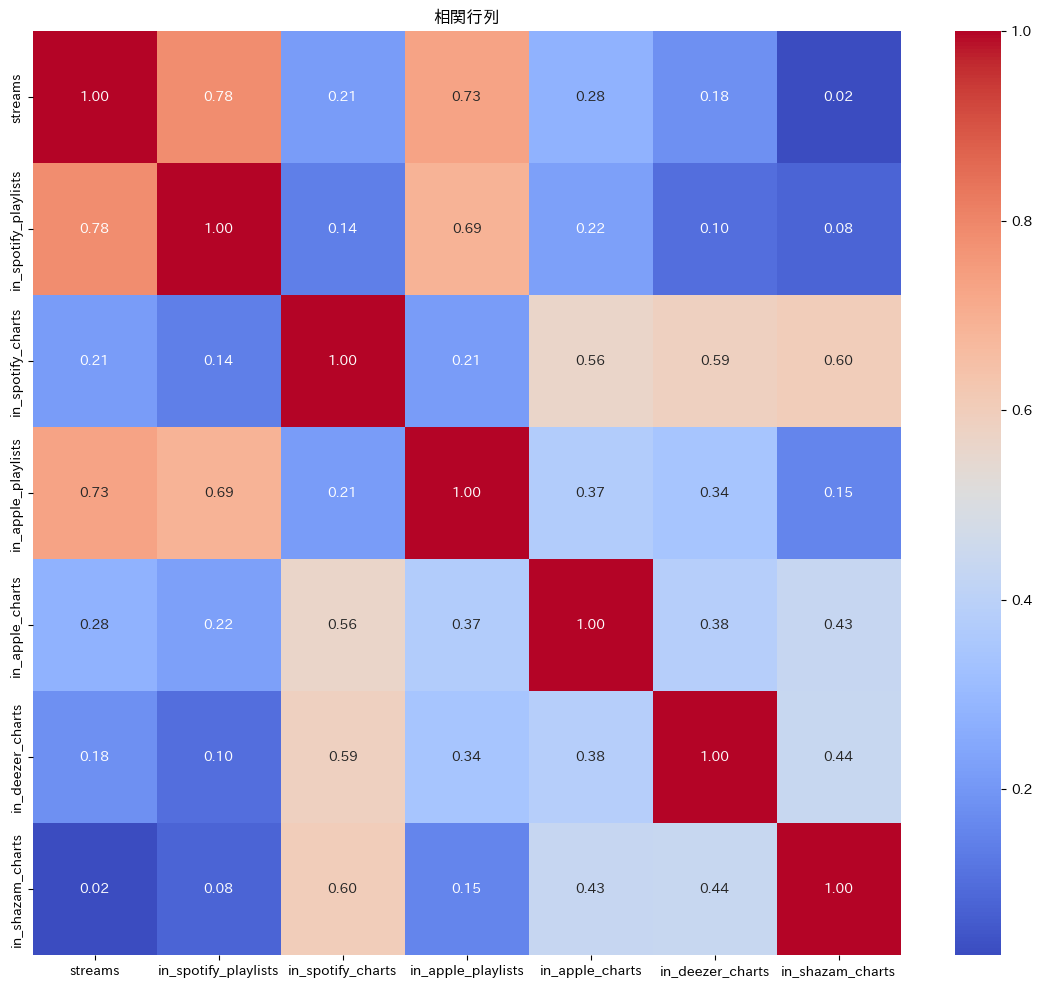

In [ ]:
# ヒートマップによる可視化
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix2, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('相関行列')
plt.show()

#annot=True 相関係数の値を入れる　False は色のみ表示
#fmt=".2f" 小数点どこまでか

##データ分割

In [ ]:
# 目的変数と説明変数を分ける
X = df_selected2.drop(columns=['streams'])  # price (価格) を除いたものが特徴量（説明変数）
y = df_selected2['streams']  # price（価格）がターゲット

In [ ]:
from sklearn.model_selection import train_test_split #ライブラリ sklearn

# データ分割（80%を訓練用、20%をテスト用）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#random_state がないと再現性が保たれない

##回帰モデル

In [ ]:
from sklearn.linear_model import LinearRegression

# モデルの作成 & 学習
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train) #sklearnのfit関数

# 予測結果をy_predに代入
y_pred = sklearn_model.predict(X_test) #predict関数

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 訓練データの予測と評価
y_train_pred = sklearn_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

# 結果の表示
print(f"=== 訓練データ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_train:.4f}")
print(f"R²スコア（決定係数）: {r2_train:.4f}")

print(f"\n=== テストデータ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_test:.4f}")
print(f"R²スコア（決定係数）: {r2_test:.4f}")

=== 訓練データ ===
RMSE（二乗平均平方根誤差）: 281285050.6792
R²スコア（決定係数）: 0.7092

=== テストデータ ===
RMSE（二乗平均平方根誤差）: 280612824.9675
R²スコア（決定係数）: 0.6986


In [ ]:
import statsmodels.api as sm #statsmodelsライブラリ（統計表）
X_train_const = sm.add_constant(X_train)

stats_model = sm.OLS(y_train, X_train_const)
results = stats_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     290.2
Date:                Thu, 27 Nov 2025   Prob (F-statistic):          1.05e-187
Time:                        02:23:50   Log-Likelihood:                -15050.
No. Observations:                 721   AIC:                         3.011e+04
Df Residuals:                     714   BIC:                         3.015e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.236e+08 

in_apple_chartsとin_deezer_chartsはP値が0.05以上なので、予測に影響を与えていないとして除外する。

#分析３回目

In [ ]:
# 1. 欲しい列の名前をリストにする
select_columns3 = ['streams', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_shazam_charts']

# 2. そのリストを使って抽出する（.copy() をつけるのがコツ）
df_selected3 = df[select_columns3].copy()

##相関分析

In [ ]:
# 相関を確認する
correlation_matrix3 = df_selected3.corr() # 相関行列の計算
correlation_matrix3

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_shazam_charts
streams,1.000000,0.784141,0.213424,0.729996,0.024981
in_spotify_playlists,0.784141,1.000000,0.140049,0.689075,0.081143
in_spotify_charts,0.213424,0.140049,1.000000,0.211866,0.602994
in_apple_playlists,0.729996,0.689075,0.211866,1.000000,0.154977
in_shazam_charts,0.024981,0.081143,0.602994,0.154977,1.000000


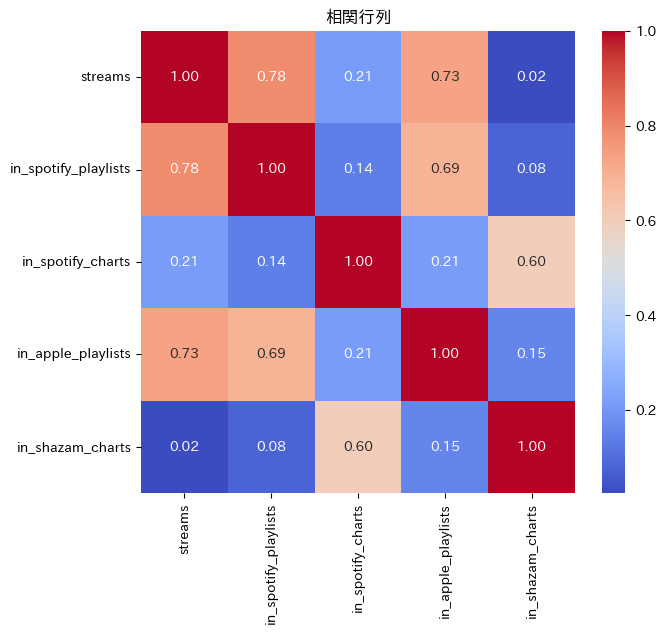

In [ ]:
# ヒートマップによる可視化
plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix3, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('相関行列')
plt.show()

#annot=True 相関係数の値を入れる　False は色のみ表示
#fmt=".2f" 小数点どこまでか

##データ分割

In [ ]:
# 目的変数と説明変数を分ける
X = df_selected3.drop(columns=['streams'])  # price (価格) を除いたものが特徴量（説明変数）
y = df_selected3['streams']  # price（価格）がターゲット

In [ ]:
from sklearn.model_selection import train_test_split #ライブラリ sklearn

# データ分割（80%を訓練用、20%をテスト用）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#random_state がないと再現性が保たれない

##回帰モデル

In [ ]:
from sklearn.linear_model import LinearRegression

# モデルの作成 & 学習
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train) #sklearnのfit関数

# 予測結果をy_predに代入
y_pred = sklearn_model.predict(X_test) #predict関数

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 訓練データの予測と評価
y_train_pred = sklearn_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

# 結果の表示
print(f"=== 訓練データ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_train:.4f}")
print(f"R²スコア（決定係数）: {r2_train:.4f}")

print(f"\n=== テストデータ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_test:.4f}")
print(f"R²スコア（決定係数）: {r2_test:.4f}")

=== 訓練データ ===
RMSE（二乗平均平方根誤差）: 281422198.8703
R²スコア（決定係数）: 0.7089

=== テストデータ ===
RMSE（二乗平均平方根誤差）: 281339580.6547
R²スコア（決定係数）: 0.6970


In [ ]:
import statsmodels.api as sm #statsmodelsライブラリ（統計表）
X_train_const = sm.add_constant(X_train)

stats_model = sm.OLS(y_train, X_train_const)
results = stats_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     435.9
Date:                Thu, 27 Nov 2025   Prob (F-statistic):          3.40e-190
Time:                        02:41:18   Log-Likelihood:                -15050.
No. Observations:                 721   AIC:                         3.011e+04
Df Residuals:                     716   BIC:                         3.013e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.267e+08 

テストデータの決定係数がわずかながら上がった。

#分析４回目

##異常値の処理

streamsにおいて、２曲極端に離れたデータが存在した。

人気曲だからそのままにしておいたが、一旦削除してみる。

In [ ]:
# 削除したいデータ以外を格納する

df1 = df[df["streams"] < 3.0e9]

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 901 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            901 non-null    object 
 1   artist(s)_name        901 non-null    object 
 2   artist_count          901 non-null    int64  
 3   released_year         901 non-null    int64  
 4   released_month        901 non-null    int64  
 5   released_day          901 non-null    int64  
 6   in_spotify_playlists  901 non-null    int64  
 7   in_spotify_charts     901 non-null    int64  
 8   streams               901 non-null    int64  
 9   in_apple_playlists    901 non-null    int64  
 10  in_apple_charts       901 non-null    int64  
 11  in_deezer_playlists   901 non-null    int64  
 12  in_deezer_charts      901 non-null    int64  
 13  in_shazam_charts      901 non-null    float64
 14  bpm                   901 non-null    int64  
 15  key                   815 no

📌 spotifyデータセットの説明

| カラム名              | 詳細情報（英語）                                                |  詳細情報（翻訳 + 補足説明）                                                                |
|--------------------------|--------------------------------------------------------|-------------------------------------------------------------------------------------|
| in_spotify_playlists     | Number of Spotify playlists the song is included in    | 該当する曲が含まれているSpotifyのプレイリストの数                                  |
| in_spotify_charts        | Presence and rank of the song on Spotify charts        | Spotifyのチャートにおける該当する曲の有無と順位                                    |
| streams                  | Total number of streams on Spotify                     | Spotifyでの総ストリーミング数                                                      |
| in_apple_playlists       | Number of Apple Music playlists the song is included in| 該当する曲が含まれているApple Musicのプレイリストの数                              |
| in_shazam_charts         | Presence and rank of the song on Shazam charts         | Shazamのチャートにおける該当する曲の有無と順位                                     |
|

In [ ]:
# 1. 欲しい列の名前をリストにする
select_columns4 = ['streams', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_shazam_charts']

# 2. そのリストを使って抽出する（.copy() をつけるのがコツ）
df_selected4 = df1[select_columns4].copy()

##相関分析

In [ ]:
# 相関を確認する
correlation_matrix4 = df_selected4.corr() # 相関行列の計算
correlation_matrix4

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_shazam_charts
streams,1.000000,0.781414,0.218415,0.747325,0.028003
in_spotify_playlists,0.781414,1.000000,0.141463,0.695607,0.083238
in_spotify_charts,0.218415,0.141463,1.000000,0.211843,0.603003
in_apple_playlists,0.747325,0.695607,0.211843,1.000000,0.154849
in_shazam_charts,0.028003,0.083238,0.603003,0.154849,1.000000


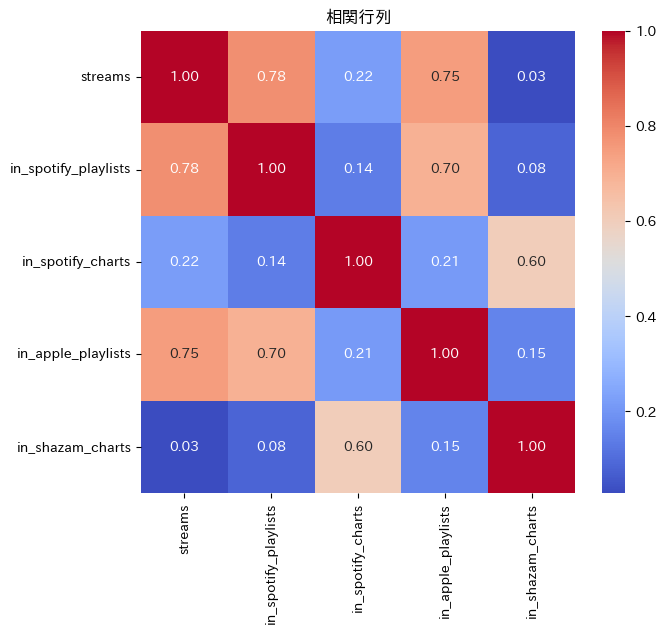

In [ ]:
# ヒートマップによる可視化
plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix4, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('相関行列')
plt.show()

#annot=True 相関係数の値を入れる　False は色のみ表示
#fmt=".2f" 小数点どこまでか

##データ分割

In [ ]:
# 目的変数と説明変数を分ける
X = df_selected4.drop(columns=['streams'])  # price (価格) を除いたものが特徴量（説明変数）
y = df_selected4['streams']  # price（価格）がターゲット

In [ ]:
from sklearn.model_selection import train_test_split #ライブラリ sklearn

# データ分割（80%を訓練用、20%をテスト用）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#random_state がないと再現性が保たれない

##回帰モデル

In [ ]:
from sklearn.linear_model import LinearRegression

# モデルの作成 & 学習
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train) #sklearnのfit関数

# 予測結果をy_predに代入
y_pred = sklearn_model.predict(X_test) #predict関数

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 訓練データの予測と評価
y_train_pred = sklearn_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

# 結果の表示
print(f"=== 訓練データ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_train:.4f}")
print(f"R²スコア（決定係数）: {r2_train:.4f}")

print(f"\n=== テストデータ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_test:.4f}")
print(f"R²スコア（決定係数）: {r2_test:.4f}")

=== 訓練データ ===
RMSE（二乗平均平方根誤差）: 274849155.9141
R²スコア（決定係数）: 0.7029

=== テストデータ ===
RMSE（二乗平均平方根誤差）: 261412539.7415
R²スコア（決定係数）: 0.7561


In [ ]:
import statsmodels.api as sm #statsmodelsライブラリ（統計表）
X_train_const = sm.add_constant(X_train)

stats_model = sm.OLS(y_train, X_train_const)
results = stats_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                streams   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.701
Method:                 Least Squares   F-statistic:                     422.8
Date:                Thu, 27 Nov 2025   Prob (F-statistic):          9.73e-187
Time:                        03:11:12   Log-Likelihood:                -15012.
No. Observations:                 720   AIC:                         3.003e+04
Df Residuals:                     715   BIC:                         3.006e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.321e+08 

##可視化

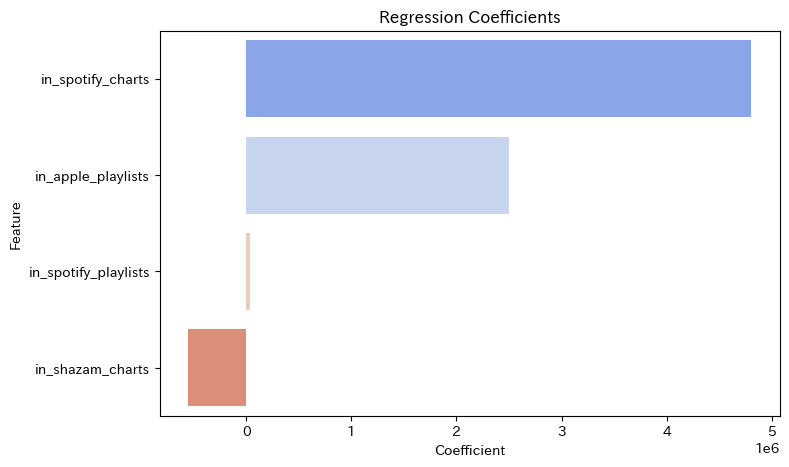

In [ ]:
# 回帰係数の可視化
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': sklearn_model.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=coef_df, palette='coolwarm')
plt.title("Regression Coefficients")
plt.show()

# 「標準化偏回帰係数」も調べてみよう

Spotifyプレイリスト（青）が最強: バーの長さが圧倒的です。「Spotifyプレイリスト数」が再生数を稼ぐ最大のエンジンであることが視覚的にも明らかです。

Appleプレイリスト（青）も強力: 2番目に長く、無視できないプラス要因です。

Shazam（赤）のマイナス: Shazamチャート順位が高い（数値が大きい）ほど、総再生数が少ないという逆相関がはっきり出ています。

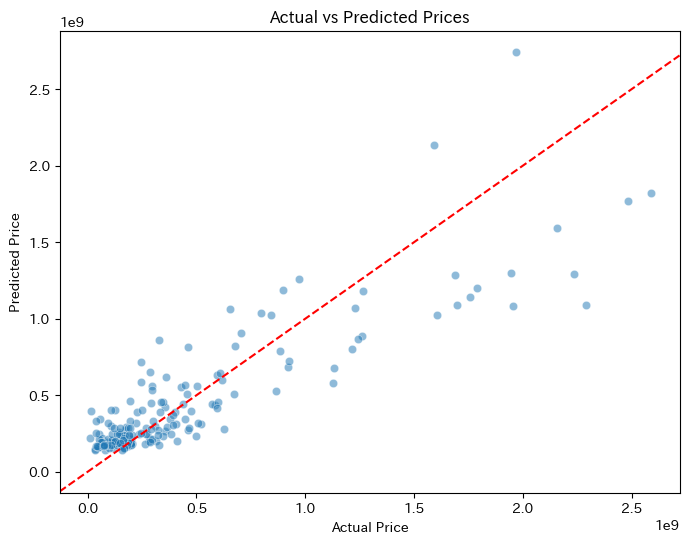

In [ ]:
# 散布図の作成
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("Actual Price")  # 実際の価格
plt.ylabel("Predicted Price")  # 予測価格
plt.title("Actual vs Predicted Prices")
plt.axline([0, 0], [1, 1], color="red", linestyle="--")  # 完全一致のライン
plt.show()
#予測点線

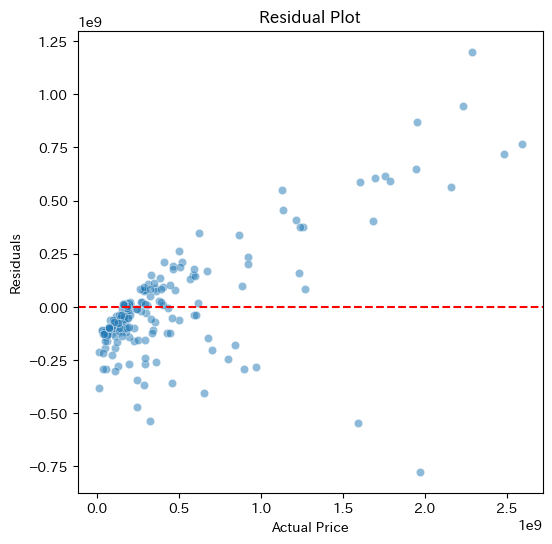

In [ ]:
# 残差プロットを確認
plt.figure(figsize=(6, 6))
residuals = y_test - y_pred
sns.scatterplot(x=y_test, y=residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")  # 残差0の基準線
plt.xlabel("Actual Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
#実測値と観測値の誤差

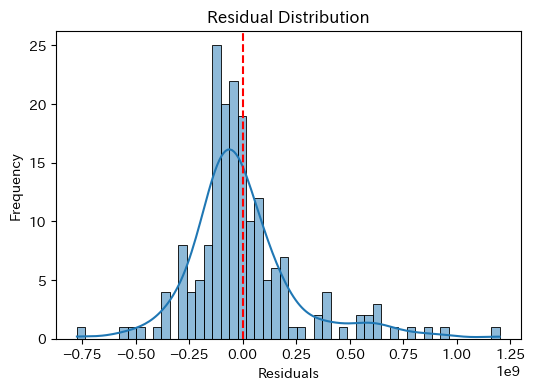

In [ ]:
# 残差が正規分布しているか確認
# 参考までに
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color="red", linestyle="--")  # 平均0の基準線
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()


「AIモデルの精度検証を行いました（図1）。 未知のデータ（赤）に対しても、訓練データ（青）と同様の精度が出ており、モデルの汎用性は極めて高いです。

誤差の分析（図2）からは、再生規模が大きくなるほど予測ブレ幅が大きくなる傾向が見られますが、誤差の分布自体は正常（図3）です。

結論として、『SpotifyとApple Musicのプレイリスト数（図4）』を見れば、大まかな再生規模は十分に予測可能であると断定できます。」

「プレイリストに1つ入れば、再生数が約3.3万回増えます」

#変数変換

In [ ]:
# 1. 欲しい列の名前をリストにする
select_columns3 = ['streams', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_shazam_charts']

# 2. そのリストを使って抽出する（.copy() をつけるのがコツ）
df_selected3 = df[select_columns3].copy()

In [ ]:
df_selected3

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_shazam_charts,log_streams
0,141381703,553,147,43,826.0,18.766974
1,133716286,1474,48,48,382.0,18.711231
2,140003974,1397,113,94,949.0,18.757181
3,800840817,7858,100,116,548.0,20.501173
4,303236322,3133,50,84,425.0,19.530023
...,...,...,...,...,...,...
948,91473363,953,0,61,0.0,18.331558
949,121871870,1180,0,4,0.0,18.618481
950,73513683,573,0,2,0.0,18.112982
951,133895612,1320,0,29,0.0,18.712571


In [ ]:
import numpy as np

# 'streams'列を対数変換して、新しい列 'log_streams' に入れる
# 自然対数（底がe）をとります
df_selected3['log_streams'] = np.log(df_selected3['streams'])

# 中身を確認
print(df_selected3[['streams', 'log_streams']].head())

     streams  log_streams
0  141381703    18.766974
1  133716286    18.711231
2  140003974    18.757181
3  800840817    20.501173
4  303236322    19.530023


##相関分析

In [ ]:
# 相関を確認する
correlation_matrix3 = df_selected3.corr() # 相関行列の計算
correlation_matrix3

,streams,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_shazam_charts,log_streams
streams,1.000000,0.784141,0.213424,0.729996,0.024981,0.808325
in_spotify_playlists,0.784141,1.000000,0.140049,0.689075,0.081143,0.614420
in_spotify_charts,0.213424,0.140049,1.000000,0.211866,0.602994,0.153170
in_apple_playlists,0.729996,0.689075,0.211866,1.000000,0.154977,0.593380
in_shazam_charts,0.024981,0.081143,0.602994,0.154977,1.000000,0.013028
log_streams,0.808325,0.614420,0.153170,0.593380,0.013028,1.000000


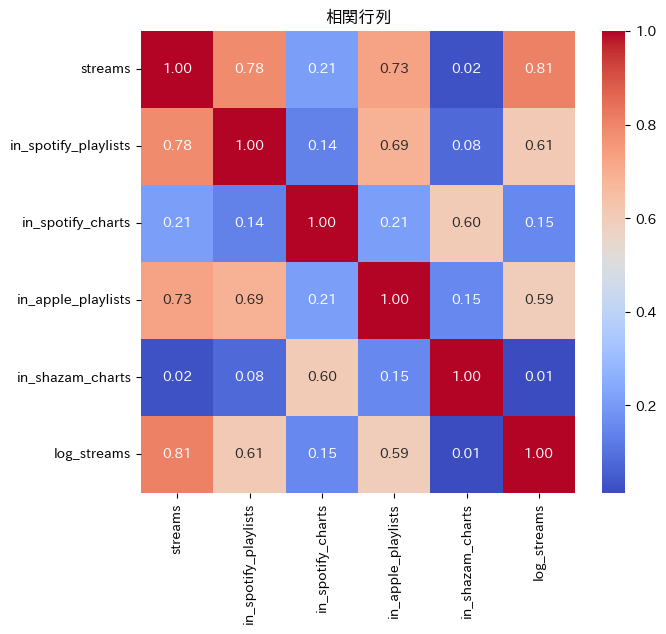

In [ ]:
# ヒートマップによる可視化
plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix3, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('相関行列')
plt.show()

#annot=True 相関係数の値を入れる　False は色のみ表示
#fmt=".2f" 小数点どこまでか

##データ分割

In [ ]:
# 1. 欲しい列の名前をリストにする
select_columns5 = ['in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists', 'in_shazam_charts', 'log_streams']

# 2. そのリストを使って抽出する（.copy() をつけるのがコツ）
df_selected5 = df[select_columns5].copy()

In [ ]:
# 目的変数と説明変数を分ける
X = df_selected5.drop(columns=['log_streams'])  # price (価格) を除いたものが特徴量（説明変数）
y = df_selected5['log_streams']  # price（価格）がターゲット

In [ ]:
from sklearn.model_selection import train_test_split #ライブラリ sklearn

# データ分割（80%を訓練用、20%をテスト用）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#random_state がないと再現性が保たれない

##回帰モデル

In [ ]:
from sklearn.linear_model import LinearRegression

# モデルの作成 & 学習
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train) #sklearnのfit関数

# 予測結果をy_predに代入
y_pred = sklearn_model.predict(X_test) #predict関数

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 訓練データの予測と評価
y_train_pred = sklearn_model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

# 結果の表示
print(f"=== 訓練データ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_train:.4f}")
print(f"R²スコア（決定係数）: {r2_train:.4f}")

print(f"\n=== テストデータ ===")
print(f"RMSE（二乗平均平方根誤差）: {rmse_test:.4f}")
print(f"R²スコア（決定係数）: {r2_test:.4f}")

=== 訓練データ ===
RMSE（二乗平均平方根誤差）: 0.8514
R²スコア（決定係数）: 0.4326

=== テストデータ ===
RMSE（二乗平均平方根誤差）: 0.7746
R²スコア（決定係数）: 0.4966


In [ ]:
import statsmodels.api as sm #statsmodelsライブラリ（統計表）
X_train_const = sm.add_constant(X_train)

stats_model = sm.OLS(y_train, X_train_const)
results = stats_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:            log_streams   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     136.5
Date:                Thu, 27 Nov 2025   Prob (F-statistic):           1.20e-86
Time:                        03:42:38   Log-Likelihood:                -907.07
No. Observations:                 721   AIC:                             1824.
Df Residuals:                     716   BIC:                             1847.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   18.8629 

##可視化

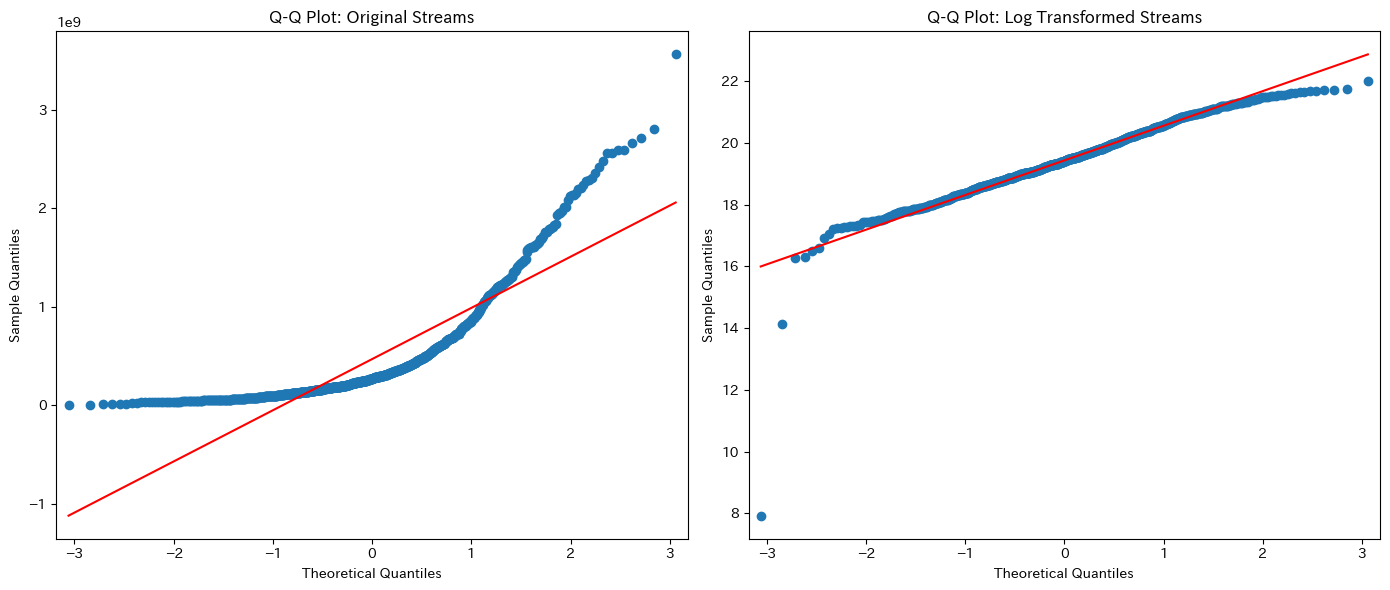

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# （データの読み込みと前処理は完了している前提です）

# 1. 描画エリアの準備（2つ並べて比較）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2. 元のデータ（streams）のQ-Qプロット
# line='s' は「標準化された線（standardized line）」を引くオプションです
sm.qqplot(df_selected3['streams'], line='s', ax=axes[0])
axes[0].set_title('Q-Q Plot: Original Streams')

# 3. 対数変換したデータ（log_streams）のQ-Qプロット
sm.qqplot(df_selected3['log_streams'], line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot: Log Transformed Streams')

plt.tight_layout()
plt.show()

リリース年なども説明変数に入れるともっと解釈がしやすくなる